# Pipeline Debug & Verification

**Goal:** Visually verify that the subject-aware splits are clean (no leakage) and that preprocessing is applied correctly.

**Steps:**
1. Load Data
2. Verify Subject Splits (No Overlap)
3. Inspect Class Balance
4. Visualize Preprocessing Distributions (Before vs. After)
5. Sanity Check: Model Baseline

In [4]:
# --- 1. Setup & Imports ---
# We import our custom modules and visualization libraries.
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# Ensure the src folder is in the path so we can import your modules
# sys.path.append(str(Path.cwd().parent))

# Import your project modules
from src.data.loader import load_data_from_path
from src.data.splits import split_by_subject
from src.data.preprocessing import fit_transform_pipeline

# Set plot style
sns.set_theme(style="whitegrid")
%matplotlib inline

now = datetime.now()

print(f"Last execution: {now}")

Last execution: 2026-08-13 14:50:50.025426


In [ ]:
# --- 2. Configuration ---
# Define paths and columns exactly as in your config.yaml
DATA_PATH = "../data/openface_features_with_metadata_stressID_resized_ExtraFeatures.csv"

TARGET_COL = "label"
SUBJECT_COL = "subject_id"
NUMERICAL_COLS = [
    "gaze_yaw", "gaze_pitch", "au01", "au02", "au03", 
    "au04", "au05", "au06", "au07", "au08"
]
CATEGORICAL_COLS = ["activity"]

print(f" Configuration loaded. Data path: {DATA_PATH}")

✅ Configuration loaded. Data path: ../data/openface_features_with_metadata_stressID_resized_ExtraFeatures.csv


In [ ]:
# --- 3. Load & Split Data ---
# We run your actual pipeline functions to get the dataframes.
print("Loading data...")
df = load_data_from_path(DATA_PATH)

print("Splitting by subject...")
train_df, val_df, test_df = split_by_subject(
    df, 
    subject_col=SUBJECT_COL,
    train_size=0.8, 
    val_size=0.1, 
    test_size=0.1, 
    random_state=42
)

print(f" Split Complete: Train subjects={train_df["subject_id"].nunique()}, Val={val_df["subject_id"].nunique()}, Test={test_df["subject_id"].nunique()}")
train_df.head(5)

Loading data...
Splitting by subject...
✅ Split Complete: Train subjects=42, Val=5, Test=6


,path,str_label,label,gaze_yaw,gaze_pitch,au01,au02,au03,au04,au05,au06,au07,au08,subject_id,activity
0,/home/jovyan/projects/Vision-Module/data/Stres...,no-stress,0.0,-0.296733,0.141820,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,a1k9,relax
1,/home/jovyan/projects/Vision-Module/data/Stres...,no-stress,0.0,-0.376166,0.221861,0.0,0.0,0.0,0.0,0.0,0.0,0.000609,0.0,a1k9,relax
2,/home/jovyan/projects/Vision-Module/data/Stres...,no-stress,0.0,-0.377651,0.271681,0.0,0.0,0.0,0.0,0.0,0.0,0.001419,0.0,a1k9,relax
3,/home/jovyan/projects/Vision-Module/data/Stres...,no-stress,0.0,-0.395723,0.185355,0.0,0.0,0.0,0.0,0.0,0.0,0.108121,0.0,a1k9,relax
4,/home/jovyan/projects/Vision-Module/data/Stres...,no-stress,0.0,-0.208112,0.202631,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,a1k9,relax


## Verification 1: Subject Leakage Check

We must ensure that **no subject ID** appears in more than one split. If they do, our model is "cheating" by memorizing faces instead of learning stress patterns.

In [22]:
# Extract unique subjects from each set
train_subs = set(train_df[SUBJECT_COL])
val_subs = set(val_df[SUBJECT_COL])
test_subs = set(test_df[SUBJECT_COL])

# Check for intersections (overlaps)
leakage_train_val = train_subs.intersection(val_subs)
leakage_train_test = train_subs.intersection(test_subs)
leakage_val_test = val_subs.intersection(test_subs)

print("🛡️ Leakage Report:")
print(f"Train <-> Val Overlap: {len(leakage_train_val)} subjects")
print(f"Train <-> Test Overlap: {len(leakage_train_test)} subjects")
print(f"Val <-> Test Overlap: {len(leakage_val_test)} subjects")

if not leakage_train_val and not leakage_train_test and not leakage_val_test:
    print("\n✅ SUCCESS: No subject leakage detected!")
else:
    print("\n❌ CRITICAL ERROR: Subject leakage found!")

🛡️ Leakage Report:
Train <-> Val Overlap: 0 subjects
Train <-> Test Overlap: 0 subjects
Val <-> Test Overlap: 0 subjects

✅ SUCCESS: No subject leakage detected!


## Verification 2: Class Balance Distribution

We check if the ratio of Stressed vs. Non-Stressed samples is consistent across splits. Drastic imbalances might bias the model.

/tmp/ipykernel_428591/3677637124.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=ax, x=TARGET_COL, data=data, palette="viridis")
/tmp/ipykernel_428591/3677637124.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=ax, x=TARGET_COL, data=data, palette="viridis")
/tmp/ipykernel_428591/3677637124.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=ax, x=TARGET_COL, data=data, palette="viridis")


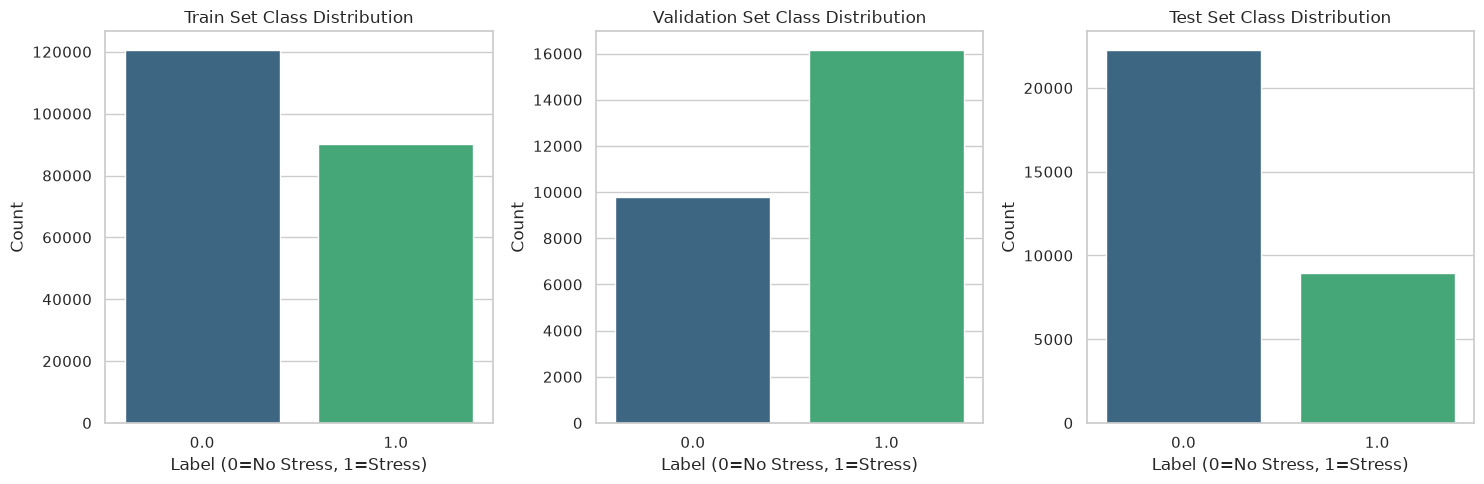

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Plot distribution for each split
for ax, data, name in zip(axes, [df, train_df, val_df, test_df], ['Dataset', 'Train', 'Validation', 'Test']):
    # Create the countplot
    # Note: stat='percent' makes the bar height equal to the percentage
    plot = sns.countplot(ax=ax, x=TARGET_COL, data=data, palette="viridis", stat='percent')
    
    ax.set_title(f'{name} Set Class Distribution')
    ax.set_xlabel('Label (0=No Stress, 1=Stress)')
    ax.set_ylabel('Percentage')
    
    # CRITICAL FIX: Iterate over ALL containers in the axis
    # Even without explicit 'hue', countplot returns a list of containers.
    for container in plot.containers:
        # fmt='%.1f%%' formats the height (which is already a percent) to 1 decimal place
        ax.bar_label(container, fmt='%.4f%%')

plt.tight_layout()
plt.show()

## Verification 3: Preprocessing Impact (Before vs. After)

We visualize the `gaze_yaw` feature (numerical) to confirm:
1. **Before:** Data might have different scales or outliers.
2. **After:** Data is centered at 0 with unit variance (StandardScaler).

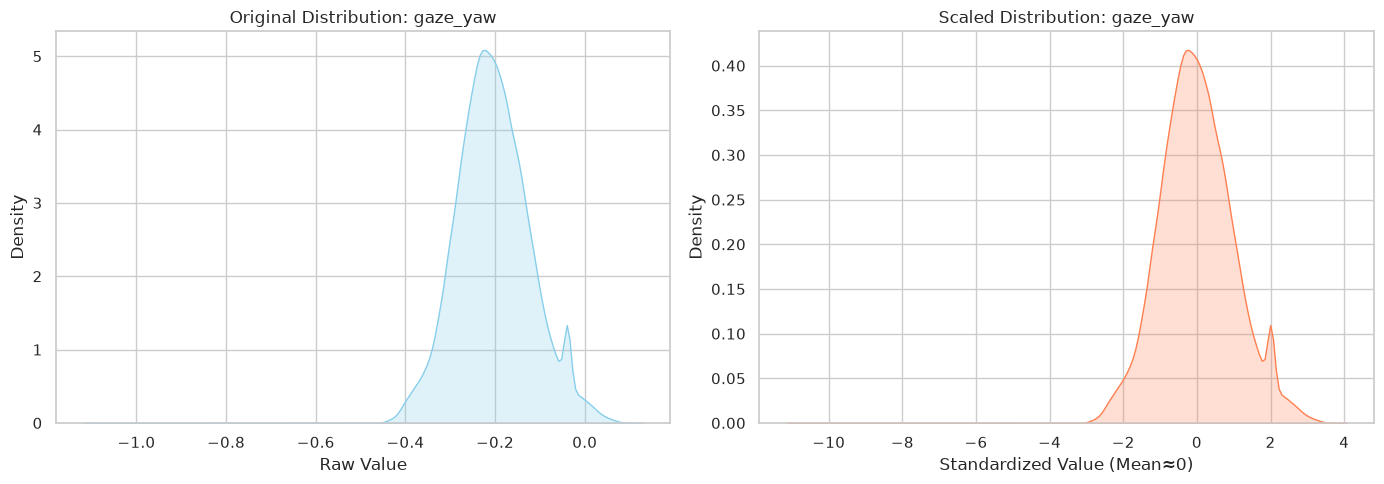

✅ Mean of Scaled Data: 0.00000 (Should be ~0)
✅ Std Dev of Scaled Data: 1.00000 (Should be ~1)


In [24]:
# Run preprocessing to get transformed arrays
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor = fit_transform_pipeline(
    train_df, val_df, test_df, NUMERICAL_COLS, CATEGORICAL_COLS, TARGET_COL
)

# Convert back to DataFrame for easy plotting (using first numerical feature)
feature_name = "gaze_yaw"
feature_idx = NUMERICAL_COLS.index(feature_name)

plot_df = pd.DataFrame({
    'Original_Train': train_df[feature_name],
    'Scaled_Train': X_train[:, feature_idx]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Original
sns.kdeplot(ax=axes[0], data=plot_df, x='Original_Train', fill=True, color='skyblue')
axes[0].set_title(f'Original Distribution: {feature_name}')
axes[0].set_xlabel('Raw Value')

# Plot Scaled
sns.kdeplot(ax=axes[1], data=plot_df, x='Scaled_Train', fill=True, color='coral')
axes[1].set_title(f'Scaled Distribution: {feature_name}')
axes[1].set_xlabel('Standardized Value (Mean≈0)')

plt.tight_layout()
plt.show()

print(f"✅ Mean of Scaled Data: {plot_df['Scaled_Train'].mean():.5f} (Should be ~0)")
print(f"✅ Std Dev of Scaled Data: {plot_df['Scaled_Train'].std():.5f} (Should be ~1)")

In [27]:
X_train

array([[-1.13225672,  0.63580589, -0.31442575, ...,  0.        ,
         0.        ,  0.        ],
       [-2.09955223,  1.32102811, -0.31442575, ...,  0.        ,
         0.        ,  0.        ],
       [-2.11763637,  1.74753807, -0.31442575, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.59367026,  0.34338691,  0.10001903, ...,  0.        ,
         0.        ,  0.        ],
       [-0.55127116, -0.97957135, -0.31442575, ...,  0.        ,
         0.        ,  0.        ],
       [-0.30122145, -0.04346989, -0.11932456, ...,  0.        ,
         0.        ,  0.        ]], shape=(210607, 21))

## Verification 4: Quick Baseline Sanity Check

We train a tiny model just to ensure the pipeline doesn't crash and produces probabilities.

In [ ]:
from src.models.factory import ModelFactory
from sklearn.metrics import accuracy_score

# Initialize a simple model
model = ModelFactory.get_model("logistic_regression", random_state=42, max_iter=1000)

# Train
print("Training sanity check model...")
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)

print(f"Sanity Check Complete. Test Accuracy: {acc:.2f}")
print("If this ran without error, your pipeline is ready for the full trainer!")

Training sanity check model...
✅ Sanity Check Complete. Test Accuracy: 0.79
If this ran without error, your pipeline is ready for the full trainer!
